In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier, plot_importance
from sklearn.preprocessing import StandardScaler
import joblib

In [2]:
# Load Credit Score Classification Dataset

import numpy as np
np.random.seed(42)
    
n_samples = 1000
df = pd.DataFrame({
        'income': np.random.uniform(20000, 150000, n_samples),
        'age': np.random.randint(20, 65, n_samples),
        'employment_years': np.random.randint(0, 40, n_samples),
        'loan_amount': np.random.uniform(5000, 500000, n_samples),
        'loan_term': np.random.randint(12, 240, n_samples),
        'credit_history_length': np.random.randint(0, 40, n_samples),
        'num_credit_lines': np.random.randint(0, 10, n_samples),
        'num_delinquencies': np.random.randint(0, 5, n_samples),
        'debt_to_income_ratio': np.random.uniform(0, 1, n_samples),
        'savings_balance': np.random.uniform(0, 50000, n_samples),
})
    # Create target: approved (1) or rejected (0)
df['approved'] = (df['income'] > 40000) & (df['num_delinquencies'] < 2) & (df['debt_to_income_ratio'] < 0.7)
df['approved'] = df['approved'].astype(int)

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nTarget distribution:")
print(df['approved'].value_counts())

Dataset shape: (1000, 11)

First few rows:
          income  age  employment_years    loan_amount  loan_term  \
0   68690.215450   31                 2  447079.651572        233   
1  143592.859833   35                34   35916.508841        121   
2  115159.212435   43                 5  442315.057678         31   
3   97825.602946   38                24  226917.932408        135   
4   40282.423258   27                12  257664.082057         64   

   credit_history_length  num_credit_lines  num_delinquencies  \
0                     15                 8                  4   
1                      1                 6                  1   
2                     29                 5                  1   
3                     19                 9                  1   
4                     37                 0                  1   

   debt_to_income_ratio  savings_balance  approved  
0              0.883193     30547.974972         0  
1              0.948199      2006.231013     

In [3]:
# Prepare data for modeling
X = df.drop('approved', axis=1)
y = df['approved']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Target balance:\n", y.value_counts(normalize=True))

Features shape: (1000, 10)
Target shape: (1000,)
Target balance:
 approved
0    0.766
1    0.234
Name: proportion, dtype: float64


In [4]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set size: 800
Test set size: 200


In [5]:
# Train XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_train = xgb_model.predict(X_train_scaled)
y_pred_test = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("Model trained successfully!")

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:42:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model trained successfully!


In [6]:
# Model Evaluation
from sklearn.metrics import classification_report

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 50)
print("MODEL EVALUATION METRICS")
print("=" * 50)
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
print("\nConfusion Matrix:")
print(cm)

MODEL EVALUATION METRICS
Train Accuracy: 1.0000
Test Accuracy: 1.0000
ROC AUC Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00        47

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


Confusion Matrix:
[[153   0]
 [  0  47]]


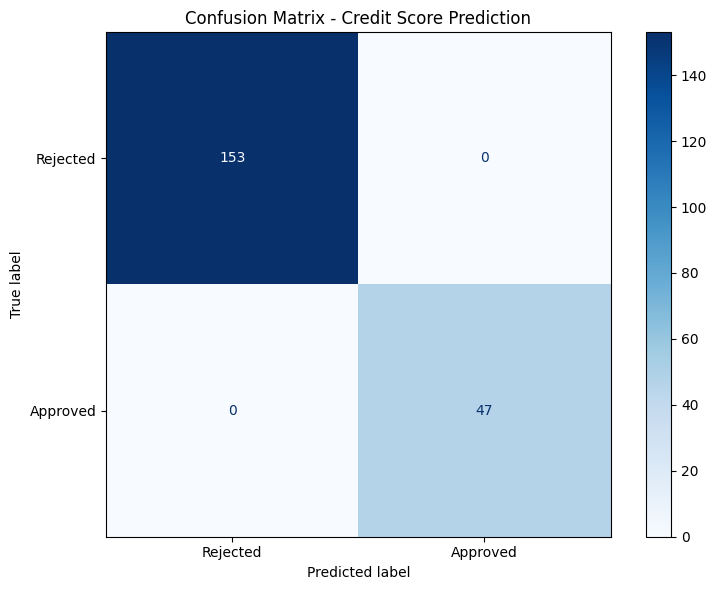

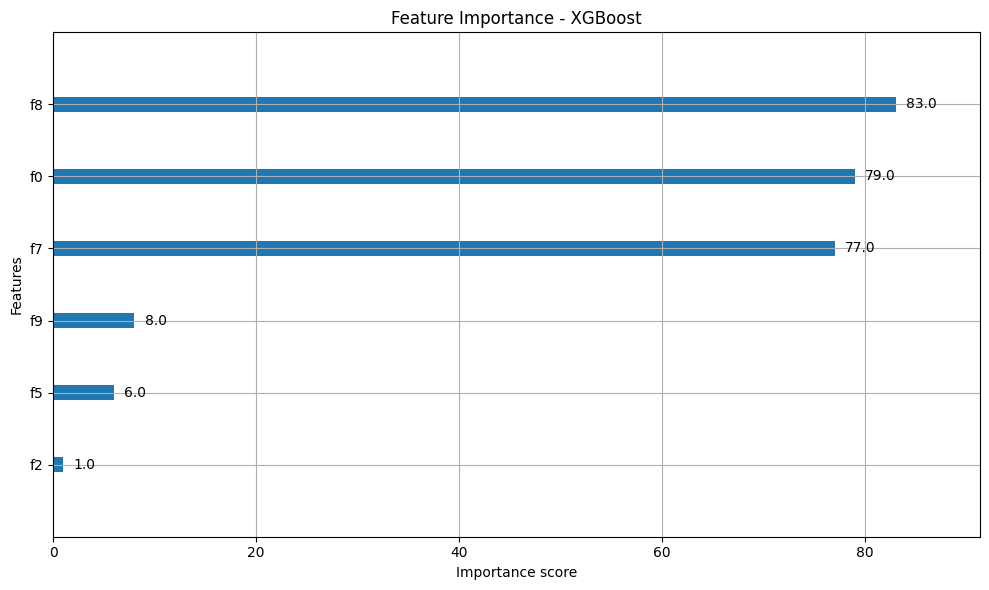

In [7]:
# Visualize Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected', 'Approved'])
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix - Credit Score Prediction')
plt.tight_layout()
plt.show()

# Feature Importance
fig, ax = plt.subplots(figsize=(10, 6))
plot_importance(xgb_model, ax=ax, max_num_features=15)
plt.title('Feature Importance - XGBoost')
plt.tight_layout()
plt.show()

In [8]:
# Export Model and Scaler
import os
import joblib
import json

# Create model directory
model_dir = "credit_model"

if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Save model
model_path = os.path.join(model_dir, "xgb_model.pkl")
joblib.dump(xgb_model, model_path)
print(f"✓ Model saved: {model_path}")

# Save scaler
scaler_path = os.path.join(model_dir, "scaler.pkl")
joblib.dump(scaler, scaler_path)
print(f"✓ Scaler saved: {scaler_path}")

# Save feature names
feature_names = X.columns.tolist()
feature_names_path = os.path.join(model_dir, "feature_names.json")

with open(feature_names_path, 'w') as f:
    json.dump(feature_names, f)

print(f"✓ Feature names saved: {feature_names_path}")

# Save metadata
metadata = {
    "model_type": "XGBClassifier",
    "train_accuracy": float(train_accuracy),
    "test_accuracy": float(test_accuracy),
    "roc_auc": float(roc_auc),
    "n_features": len(feature_names),
    "feature_names": feature_names
}

metadata_path = os.path.join(model_dir, "metadata.json")

with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Metadata saved: {metadata_path}")

print("\n" + "=" * 50)
print("ALL FILES EXPORTED SUCCESSFULLY!")
print("=" * 50)

✓ Model saved: credit_model\xgb_model.pkl
✓ Scaler saved: credit_model\scaler.pkl
✓ Feature names saved: credit_model\feature_names.json
✓ Metadata saved: credit_model\metadata.json

ALL FILES EXPORTED SUCCESSFULLY!
